# 6 — Clustering-based uncertainty quantification (QRF)

This notebook reproduces and lightly extends the clustering-based Quantile
Regression Forest (QRF) framework of Al-Aghbary et al. (2026, *GJI*), applied
here to Antarctic and Greenlandic subglacial heat flow instead of continental
Africa. It is deliberately a **single-method** notebook: everything here is
built on QRF alone. Combining QRF with the GBM and similarity models happens
in notebook 7.

The logic follows the paper section by section:

| Section | What it does | Paper reference |
|---------|--------------|-----------------|
| 0 | Configuration and toggles | — |
| 1 | Load and clean the reference data | sec 3.2 |
| 1b | Coarsen the 5 km target grids to 25 km | — (resolution match) |
| 2 | k-means cluster selection (sweep K) | sec 2.3 |
| 3 | Cluster diagnostics (elbow, silhouette, PCA) | sec 2.3, A2.1 |
| 4 | Apply cluster labels to the target grids | sec 2.3 |
| 5 | Quantile Regression Forest wrapper | sec 2.4, Meinshausen 2006 |
| 6 | Per-cluster experts + baseline (Mixture-of-Experts) | sec 2.4 |
| 7 | 5-fold cross-validation → diagnostic thresholds | sec 2.2.4, 2.2.5 |
| 8 | The five diagnostic fields | eqs 1, 5, 6–14 |
| 9 | Apply to target grids, write NetCDF | — |
| 10–11 | Diagnostic and supplementary maps | Figs 9–10 |
| 12 | Save artefacts and the 7_ENSEMBLE hand-off | — |

**Uncertainty decomposition (eqs 1–4).** Total predictive variance splits into
an aleatoric part (irreducible data noise, the mean within-leaf variance) and an
epistemic part (model ignorance, the between-tree variance of leaf means). The
Mixture-of-Experts idea is that clustering the observables into homogeneous
regimes and training one QRF per regime lowers the aleatoric term where the
data are internally consistent, without inflating the epistemic term too much.


## Section 0 — Configuration and toggles

Execution toggles let you re-run any single stage without repeating the
expensive ones. Shared paths, the cluster sweep range and the QRF/MoE settings
now live in `config.py`, so this notebook and notebook 7 read exactly the same
values.

In [1]:
import sys, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
import netCDF4 as nc

sys.path.insert(0, ".")
from config import *          # paths, params and helpers (incl. to_mW, CLUSTER_DIR)

warnings.filterwarnings("ignore")

# ── Execution toggles ───────────────────────────────────────────────────────
RUN_COARSEN      = True    # False -> load saved 25-km parquets
RUN_CLUSTERING   = True    # False -> load saved k-means models
RUN_QRF_TRAINING = True    # False -> load saved expert artefacts
RUN_CV           = True    # False -> load saved CV thresholds
RUN_GRID_APPLY   = True    # False -> reuse in-memory grid diagnostics
SHOW_FIGS        = True    # display result maps inline; files are always written

# ── Cluster sweep (values from config.py) ────────────────────────────────────
NCLUSTERS_RANGE = range(NCLUSTERS_RANGE_MIN, NCLUSTERS_RANGE_MAX + 1)
NCLUSTERS_BEST  = NCLUSTERS_OVERRIDE   # None -> auto-select by Davies-Bouldin

# ── Coarsening (native 5 km -> 25 km) ────────────────────────────────────────
NATIVE_SPACING_ANT = grid_spacing_m_ant        # 5 000 m
NATIVE_SPACING_GRL = grid_spacing_m_grl        # 5 000 m
TARGET_SPACING_M   = coarsen_target_spacing_m  # 25 000 m
COARSEN_FACTOR     = TARGET_SPACING_M // NATIVE_SPACING_ANT

FIG_DIR = fig_dir_cluster   # from config.py

print(f"obs_model features : {len(obs_model)}")
print(f"NCLUSTERS sweep    : {list(NCLUSTERS_RANGE)}  (override = {NCLUSTERS_BEST})")
print(f"Coarsen factor     : {COARSEN_FACTOR}x  "
      f"({NATIVE_SPACING_ANT/1e3:.0f} km -> {TARGET_SPACING_M/1e3:.0f} km)")
print(f"Cluster dir        : {CLUSTER_DIR}")
print(f"Figure dir         : {FIG_DIR}")


✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36
obs_model features : 21
NCLUSTERS sweep    : [2, 3, 4, 5]  (override = None)
Coarsen factor     : 5x  (5 km -> 25 km)
Cluster dir        : output/clustering
Figure dir         : fig/6_CLUSTERING


## Section 1 — Load and clean the reference data

Two feature sets are used and it is worth being explicit about why:

- **`obs_sel`** — the sweep-selected QRF subset (19 features). Used to *train*
  and *predict* heat flow, so it must match the QRF sweep and the scaler.
- **`obs_model`** — the full observable catalogue (21 features). Used only for
  *clustering*, because the regime structure is a property of the whole
  observable space, not of the subset the regressor happens to prefer.

Reference rows are dropped where the QRF features or the target `q` are missing,
and `q` is clipped to the physically plausible range set in `config.py`. For
clustering, missing observables are median-imputed (the medians are stored so
the same fill is applied to the target grids later).

In [2]:
df_ref_raw = pd.read_parquet(parquet_ref)
print(f"Raw reference rows: {len(df_ref_raw):,}")

# obs_sel from the QRF artefact (single source of truth for the fitted model)
qrf_bundle = pickle.load(open(model_paths["qrf"], "rb"))
obs_sel    = qrf_bundle["obs_sel"]
assert set(obs_sel) == set(resolve_features("qrf")), \
    "obs_sel in the QRF pickle disagrees with the QRF sweep JSON"
print(f"obs_sel (QRF): {len(obs_sel)} features")

# Training matrix: complete obs_sel + valid q
cols_needed = obs_sel + ["q"]
df_ref = (df_ref_raw.dropna(subset=cols_needed)
          .query("@q_clip_min <= q <= @q_clip_max")
          .reset_index(drop=True))
X_train = df_ref[obs_sel].values.astype(np.float64)
y_train = df_ref["q"].values.astype(np.float64)
print(f"Training matrix: {X_train.shape}")

# Clustering matrix: full obs_model, median-imputed
cluster_cols   = list(obs_model)
df_cluster_ref = (df_ref_raw.dropna(subset=["q"])
                  .query("@q_clip_min <= q <= @q_clip_max")
                  .reset_index(drop=True))
cluster_medians = df_cluster_ref[cluster_cols].median()   # reused for target grids
X_clust_ref     = df_cluster_ref[cluster_cols].fillna(cluster_medians).values.astype(np.float64)
clust_scaler    = StandardScaler().fit(X_clust_ref)
X_clust_ref_sc  = clust_scaler.transform(X_clust_ref)
print(f"Clustering matrix: {X_clust_ref_sc.shape}  (NaN after impute: {np.isnan(X_clust_ref_sc).sum()})")


Raw reference rows: 30,848
obs_sel (QRF): 5 features
Training matrix: (30848, 5)
Clustering matrix: (30848, 21)  (NaN after impute: 0)


## Section 1b — Coarsen the target grids from 5 km to 25 km

The reference measurements are sparse, so a 5 km prediction grid is far finer
than the information content justifies and makes the QRF entropy/variance maps
noisy. Following the ~0.5° resolution used in the paper, each 25 km super-cell
is the `nanmean` of the up-to 25 native 5 km cells that fall inside it, computed
in one vectorised `groupby`. Super-cell coordinates are the mean of their member
cells. Cells that are entirely NaN are kept and median-imputed before
clustering, exactly as for the native grid.

In [3]:
def coarsen_grid(parquet_path, native_m, target_m, out_path):
    """Coarsen a regular projected-grid parquet from native_m to target_m by
    nanmean aggregation over target_m x target_m blocks. Returns the DataFrame."""
    factor = int(round(target_m / native_m))
    assert factor >= 1, f"target_m must be >= native_m (factor={factor})"

    df = pd.read_parquet(parquet_path)
    print(f"  native rows   : {len(df):>10,}")

    half = native_m / 2.0
    df["_bx"] = np.floor((df["x"] + half) / target_m).astype(np.int32)
    df["_by"] = np.floor((df["y"] + half) / target_m).astype(np.int32)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    agg_cols = [c for c in num_cols if c not in ("_bx", "_by")]
    agg = (df.groupby(["_bx", "_by"], sort=False)[agg_cols]
             .mean()                      # pandas mean skips NaN
             .reset_index(drop=True))
    print(f"  coarsened     : {len(agg):>10,}  (factor {factor}x)")

    out_path.parent.mkdir(parents=True, exist_ok=True)
    agg.to_parquet(out_path, index=False)
    return agg


COARSEN_JOBS = [
    ("ant", parquet_ant, parquet_ant_25km, NATIVE_SPACING_ANT),
    ("grl", parquet_grl, parquet_grl_25km, NATIVE_SPACING_GRL),
]

if RUN_COARSEN:
    for label, src, dst, native in COARSEN_JOBS:
        print(f"{label.upper()}  {src} -> {dst}")
        coarsen_grid(src, native, TARGET_SPACING_M, dst)
else:
    for label, _, dst, _ in COARSEN_JOBS:
        print(f"{label.upper()}: using existing {dst}  "
              f"({len(pd.read_parquet(dst)):,} rows)")


ANT  data/antarctica.parquet -> data/antarctica_25km.parquet
  native rows   :  1,779,556
  coarsened     :     71,824  (factor 5x)
GRL  data/greenland.parquet -> data/greenland_25km.parquet
  native rows   :    172,360
  coarsened     :      6,993  (factor 5x)


## Section 2 — k-means cluster selection

k-means is run on the standardised full observable set for each candidate K.
The number of regimes is chosen by the **Davies–Bouldin** score (lower is
better), with the elbow (inertia) and silhouette reported alongside as
independent checks (paper sec 2.3, appendix A2.1). Fitted models are cached so
later stages can reload rather than refit.

In [4]:
kmeans_models, ref_labels, diag_rows = {}, {}, []

def _diag_row(ncval, km, labels):
    sil = silhouette_score(X_clust_ref_sc, labels,
                           sample_size=min(10_000, len(X_clust_ref_sc)),
                           random_state=random_state)
    db  = davies_bouldin_score(X_clust_ref_sc, labels)
    sizes = pd.Series(labels).value_counts().sort_index().tolist()
    return dict(NCLUSTERS=ncval, Inertia=round(km.inertia_, 1),
                Silhouette=round(sil, 4), Davies_Bouldin=round(db, 4),
                Cluster_sizes=sizes)

for ncval in NCLUSTERS_RANGE:
    pkl_path = CLUSTER_DIR / f"kmeans_nc{ncval}.pkl"
    if RUN_CLUSTERING:
        km = KMeans(n_clusters=ncval, random_state=random_state,
                    n_init=20, max_iter=500).fit(X_clust_ref_sc)
        pickle.dump(km, open(pkl_path, "wb"))
        labels = km.labels_
        print(f"Fitted  K={ncval}  DB={davies_bouldin_score(X_clust_ref_sc, labels):.4f}")
    else:
        km = pickle.load(open(pkl_path, "rb"))
        labels = km.predict(X_clust_ref_sc)
        print(f"Loaded  K={ncval}  from {pkl_path}")
    kmeans_models[ncval] = km
    ref_labels[ncval]    = labels
    diag_rows.append(_diag_row(ncval, km, labels))

diag_df = pd.DataFrame(diag_rows)

if NCLUSTERS_BEST is None:
    NCLUSTERS_BEST = int(diag_df.loc[diag_df["Davies_Bouldin"].idxmin(), "NCLUSTERS"])
    print(f"\nAuto-selected K = {NCLUSTERS_BEST}  (minimum Davies-Bouldin)")
else:
    print(f"\nUsing pinned K = {NCLUSTERS_BEST}")

diag_df.to_csv(CLUSTER_DIR / "cluster_diagnostics.csv", index=False)
print(diag_df.to_string(index=False))


Fitted  K=2  DB=1.4867
Fitted  K=3  DB=1.4694
Fitted  K=4  DB=1.6091
Fitted  K=5  DB=1.5966

Auto-selected K = 3  (minimum Davies-Bouldin)
 NCLUSTERS  Inertia  Silhouette  Davies_Bouldin                   Cluster_sizes
         2 461465.6      0.2704          1.4867                  [12085, 18763]
         3 399905.5      0.2506          1.4694             [5941, 17112, 7795]
         4 346870.4      0.2219          1.6091       [7624, 5679, 7111, 10434]
         5 320673.1      0.2153          1.5966 [6566, 2778, 7088, 3990, 10426]


## Section 3 — Cluster diagnostics

Three panels justify the choice of K (elbow, Davies–Bouldin, silhouette),
followed by a PCA projection that shows how separable the regimes are in the
first two principal components. Well-separated clusters in PCA space are a good
sign that the regimes are physically meaningful rather than an artefact of the
algorithm.

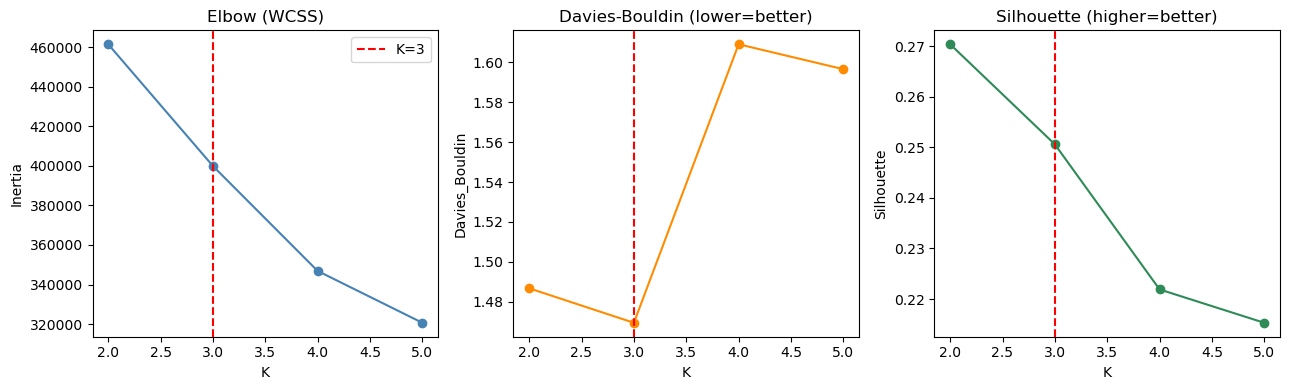

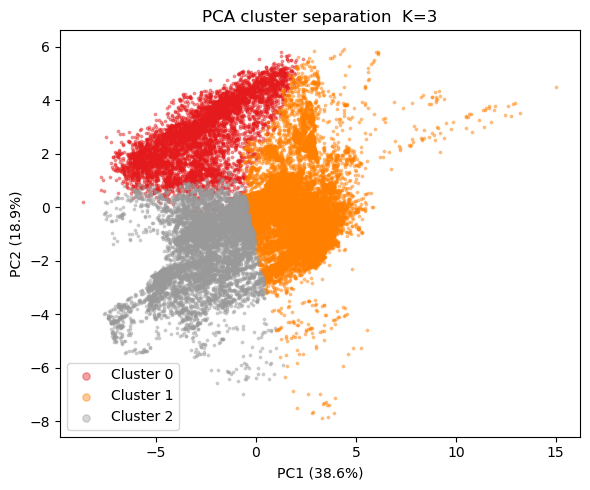

In [5]:
best_labels = ref_labels[NCLUSTERS_BEST]
best_km     = kmeans_models[NCLUSTERS_BEST]
ks = diag_df["NCLUSTERS"].values

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title, colr in [
    (axes[0], "Inertia",        "Elbow (WCSS)",              "steelblue"),
    (axes[1], "Davies_Bouldin", "Davies-Bouldin (lower=better)", "darkorange"),
    (axes[2], "Silhouette",     "Silhouette (higher=better)", "seagreen"),
]:
    ax.plot(ks, diag_df[col].values, "o-", color=colr)
    ax.axvline(NCLUSTERS_BEST, color="red", ls="--", label=f"K={NCLUSTERS_BEST}")
    ax.set_xlabel("K"); ax.set_ylabel(col); ax.set_title(title)
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / f"S_cluster_selection{FIG_EXT}", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

pca  = PCA(n_components=2, random_state=random_state)
Xpca = pca.fit_transform(X_clust_ref_sc)
ev   = pca.explained_variance_ratio_ * 100
cmap_disc = plt.get_cmap("Set1", NCLUSTERS_BEST)

fig, ax = plt.subplots(figsize=(6, 5))
for ci in range(NCLUSTERS_BEST):
    m = best_labels == ci
    ax.scatter(Xpca[m, 0], Xpca[m, 1], s=3, alpha=0.4,
               color=cmap_disc(ci), label=f"Cluster {ci}")
ax.set_xlabel(f"PC1 ({ev[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({ev[1]:.1f}%)")
ax.set_title(f"PCA cluster separation  K={NCLUSTERS_BEST}")
ax.legend(markerscale=3)
fig.tight_layout()
fig.savefig(FIG_DIR / f"S_cluster_pca{FIG_EXT}", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


## Section 4 — Apply cluster labels to the coarsened target grids

Each 25 km grid cell is assigned to the nearest regime centroid. Missing
observables are filled with the reference-set medians from Section 1 (the same
fill used when the k-means model was trained), so every subglacial cell receives
a label. This imputation is *only* for cluster assignment — the QRF inference in
Section 9 uses the raw features and handles gaps itself.

In [6]:
DOMAINS = {"ant": CRS_ANT25, "grl": CRS_GRL25}
target_labels = {}

for domain, pq_path in DOMAINS.items():
    df_tgt = pd.read_parquet(pq_path)
    for missing in [f for f in cluster_cols if f not in df_tgt.columns]:
        df_tgt[missing] = np.nan
    X_tgt = (df_tgt[cluster_cols].replace([np.inf, -np.inf], np.nan)
             .fillna(cluster_medians).values.astype(np.float64))
    lbl = kmeans_models[NCLUSTERS_BEST].predict(clust_scaler.transform(X_tgt)).astype(np.int16)
    target_labels[domain] = lbl

    coord_cols = [c for c in ("lon", "lat", "x", "y") if c in df_tgt.columns]
    out_df = df_tgt[coord_cols].copy()
    out_df[f"cluster_n{NCLUSTERS_BEST}"] = lbl
    out_df.to_parquet(CLUSTER_DIR / f"{domain}_cluster_labels.parquet", index=False)
    print(f"{domain.upper()}: {len(lbl):,} cells  "
          f"sizes={pd.Series(lbl).value_counts().sort_index().to_dict()}")


ANT: 71,824 cells  sizes={0: 31935, 1: 37359, 2: 2530}
GRL: 6,993 cells  sizes={0: 1600, 1: 4728, 2: 665}


## Section 5 — Quantile Regression Forest (Meinshausen 2006)

A thin wrapper over scikit-learn's `RandomForestRegressor` that retains every
training response in its terminal leaves, so we can read empirical quantiles and
decompose the predictive variance:

- `predict_quantile(X, q)` — empirical quantile of the pooled leaf values.
- `variance_decomposition(X)` — returns (aleatoric, epistemic):
  aleatoric = mean within-leaf variance (eq 2), epistemic = variance of the
  per-tree leaf means (eq 3).
- `robustness(X)` — R = 1 − Hₙ, the complement of the normalised Shannon entropy
  of the pooled predictive distribution (sec 2.2.1); high R means the trees
  agree.

The routines are vectorised over trees and samples. The original nested-loop
version is mathematically identical but too slow to run on ~70k grid cells;
here each tree contributes a lookup table mapping leaf id → (mean, variance,
histogram), and predictions are gathered by fancy indexing.

In [7]:
class QuantileRegressionForest(RandomForestRegressor):
    """Meinshausen (2006) QRF with vectorised quantile, variance-decomposition
    and robustness routines. Leaf response values are retained at fit time."""

    def fit(self, X, y, sample_weight=None):
        super().fit(X, y, sample_weight=sample_weight)
        y = np.asarray(y, dtype=np.float64)
        leaf_ids = self.apply(X)                       # (n_train, n_trees)
        self._y = y
        # Per-tree: leaf-id -> summary stats and pooled value arrays.
        self._leaf_mean, self._leaf_var, self._leaf_vals = [], [], []
        for t in range(self.n_estimators):
            order = np.argsort(leaf_ids[:, t], kind="stable")
            sorted_ids = leaf_ids[order, t]
            sorted_y   = y[order]
            uniq, starts = np.unique(sorted_ids, return_index=True)
            groups = np.split(sorted_y, starts[1:])
            self._leaf_mean.append({lid: g.mean()      for lid, g in zip(uniq, groups)})
            self._leaf_var.append({lid: g.var()        for lid, g in zip(uniq, groups)})
            self._leaf_vals.append({lid: g             for lid, g in zip(uniq, groups)})
        return self

    def _tree_means(self, X):
        """(n_samples, n_trees) array of per-tree leaf means."""
        lids = self.apply(X)
        out = np.empty(lids.shape, dtype=np.float64)
        for t in range(self.n_estimators):
            lut = self._leaf_mean[t]
            out[:, t] = [lut.get(l, 0.0) for l in lids[:, t]]
        return out

    def predict_mean(self, X):
        return self._tree_means(X).mean(axis=1)

    def _pool(self, X):
        """Yield the pooled leaf-value array for each sample."""
        lids = self.apply(X)
        for i in range(len(X)):
            yield np.concatenate([self._leaf_vals[t].get(lids[i, t], np.array([0.0]))
                                  for t in range(self.n_estimators)])

    def predict_quantile(self, X, q):
        return np.array([np.quantile(p, q) for p in self._pool(X)])

    def predict_quantiles(self, X, qs):
        """Several quantiles in a single pooling pass (n_samples, len(qs))."""
        qs = np.asarray(qs)
        return np.array([np.quantile(p, qs) for p in self._pool(X)])

    def variance_decomposition(self, X):
        """(aleatoric, epistemic). Aleatoric = mean within-leaf variance (eq 2);
        epistemic = variance of per-tree leaf means (eq 3)."""
        lids = self.apply(X)
        n, T = lids.shape
        mu  = np.empty((n, T)); var = np.empty((n, T))
        for t in range(T):
            m_lut, v_lut = self._leaf_mean[t], self._leaf_var[t]
            mu[:, t]  = [m_lut.get(l, 0.0) for l in lids[:, t]]
            var[:, t] = [v_lut.get(l, 0.0) for l in lids[:, t]]
        return var.mean(axis=1), mu.var(axis=1)

    def robustness(self, X, n_bins=50):
        """R = 1 - H_n, complement of normalised Shannon entropy of the pooled
        predictive distribution (sec 2.2.1). Fixed global bin edges keep the
        entropy comparable across samples."""
        lo, hi = float(self._y.min()), float(self._y.max())
        edges = np.linspace(lo, hi, n_bins + 1)
        log_nb = np.log2(n_bins)
        out = np.empty(len(X))
        for i, pooled in enumerate(self._pool(X)):
            counts, _ = np.histogram(pooled, bins=edges)
            p = counts / (counts.sum() + 1e-12)
            p = p[p > 0]
            H = -np.sum(p * np.log2(p))
            out[i] = 1.0 - H / log_nb
        return np.clip(out, 0.0, 1.0)


print("QuantileRegressionForest defined (vectorised).")


QuantileRegressionForest defined (vectorised).


## Section 6 — Per-cluster experts and baseline (Mixture-of-Experts)

Two model families are trained (paper sec 2.4):

1. **Baseline** — one global QRF on all training rows (the unclustered control).
2. **Experts** — one QRF per regime, trained only on that regime's rows.

Hyperparameters come from the QRF sweep JSON when present, otherwise from the
`config.py` defaults. Tree depth scales with sample size,
`depth = round(MOE_TREE_DEPTH_COEF · log₂ n)`, floored at `MOE_MIN_TREE_DEPTH`,
so small clusters get shallower trees and do not overfit.

In [8]:
qrf_param_path = param_paths["qrf"]
if qrf_param_path.exists():
    p = json.loads(qrf_param_path.read_text())
    NTREES  = int(p.get("n_estimators", QRF_N_ESTIMATORS))
    MAXFEAT = p.get("max_features", QRF_MAX_FEATURES)
    MINLEAF = int(p.get("min_samples_leaf", max(QRF_MIN_SAMPLES_LEAF, 3)))
    print(f"Loaded QRF params from {qrf_param_path}")
else:
    NTREES, MAXFEAT, MINLEAF = QRF_N_ESTIMATORS, QRF_MAX_FEATURES, max(QRF_MIN_SAMPLES_LEAF, 3)
    print("Using config QRF defaults")
print(f"NTREES={NTREES}  MAXFEAT={MAXFEAT}  MINLEAF={MINLEAF}")

def _depth(n):
    return max(MOE_MIN_TREE_DEPTH, round(MOE_TREE_DEPTH_COEF * np.log2(max(n, 2))))

def _make_qrf(depth):
    return QuantileRegressionForest(
        n_estimators=NTREES, max_features=MAXFEAT, min_samples_leaf=MINLEAF,
        max_depth=depth, n_jobs=QRF_N_JOBS, random_state=random_state)

# Assign each training row to a regime
X_ref_clust_sc = clust_scaler.transform(
    df_ref[cluster_cols].replace([np.inf, -np.inf], np.nan)
    .fillna(cluster_medians).values.astype(np.float64))
train_cluster_labels = kmeans_models[NCLUSTERS_BEST].predict(X_ref_clust_sc).astype(int)
df_ref = df_ref.assign(cluster=train_cluster_labels)
print(f"Training regime sizes: {pd.Series(train_cluster_labels).value_counts().sort_index().to_dict()}")

expert_models, baseline_model = {}, None
if RUN_QRF_TRAINING:
    baseline_model = _make_qrf(_depth(len(X_train))).fit(X_train, y_train)
    print(f"Baseline QRF fitted  n={len(X_train)}  depth={_depth(len(X_train))}")
    for ci in range(NCLUSTERS_BEST):
        m = train_cluster_labels == ci
        expert_models[ci] = _make_qrf(_depth(m.sum())).fit(X_train[m], y_train[m])
        print(f"Expert {ci} fitted  n={m.sum()}  depth={_depth(m.sum())}")
    pickle.dump(dict(baseline=baseline_model, experts=expert_models,
                     obs_sel=obs_sel, NCLUSTERS=NCLUSTERS_BEST),
                open(CLUSTER_DIR / f"expert_qrf_n{NCLUSTERS_BEST}.pkl", "wb"))
    print("Saved expert artefacts.")
else:
    art = pickle.load(open(CLUSTER_DIR / f"expert_qrf_n{NCLUSTERS_BEST}.pkl", "rb"))
    baseline_model, expert_models = art["baseline"], art["experts"]
    print("Loaded expert artefacts.")


Loaded QRF params from output/sweeps/qrf_params.json
NTREES=1000  MAXFEAT=0.7  MINLEAF=5
Training regime sizes: {0: 5941, 1: 17112, 2: 7795}
Baseline QRF fitted  n=30848  depth=13
Expert 0 fitted  n=5941  depth=11
Expert 1 fitted  n=17112  depth=13
Expert 2 fitted  n=7795  depth=12
Saved expert artefacts.


## Section 7 — 5-fold cross-validation → diagnostic thresholds

The confidence and explainability maps are categorical, and their category
boundaries are **not** fixed constants — the paper derives them from
cross-validated training statistics so they adapt to the data set (sec 2.2.4,
2.2.5). Running stratified 5-fold CV on the Mixture-of-Experts gives out-of-fold
predictions from which we read:

- `b_mean_cv`, `b_excess_cv`, `b_deficit_cv` — the mean, above-mean and
  below-mean bandwidth (semi-IQR) levels.
- `Rcv25`, `Rcv75` — the 25th and 75th robustness percentiles.
- `A50_cv`, `E50_cv` — the median aleatoric and epistemic variance.

Both the baseline and MoE out-of-fold predictions are kept so Section 11 can
show the clustering gain directly.

In [9]:
if RUN_CV:
    skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=random_state)
    keys = ("mean", "q25", "q75", "aleat", "epist", "robust", "ytrue")
    oof_base = {k: [] for k in keys}
    oof_moe  = {k: [] for k in keys}

    for fold_i, (tr, va) in enumerate(skf.split(X_train, train_cluster_labels)):
        print(f"  fold {fold_i+1}/{N_CV_FOLDS}", end=" ", flush=True)
        Xtr, ytr, Xva, yva = X_train[tr], y_train[tr], X_train[va], y_train[va]
        cl_tr, cl_va = train_cluster_labels[tr], train_cluster_labels[va]

        # baseline
        bf = _make_qrf(_depth(len(ytr))).fit(Xtr, ytr)
        qb = bf.predict_quantiles(Xva, [0.25, 0.75])
        ab, eb = bf.variance_decomposition(Xva)
        for k, v in dict(mean=bf.predict_mean(Xva), q25=qb[:, 0], q75=qb[:, 1],
                         aleat=ab, epist=eb, robust=bf.robustness(Xva, ENTROPY_BINS),
                         ytrue=yva).items():
            oof_base[k].append(v)

        # MoE
        pred = {k: np.full(len(yva), np.nan) for k in keys[:-1]}
        for ci in np.unique(cl_tr):
            m_tr = cl_tr == ci
            ef = _make_qrf(_depth(m_tr.sum())).fit(Xtr[m_tr], ytr[m_tr])
            m_va = cl_va == ci
            if not m_va.any():
                continue
            qm = ef.predict_quantiles(Xva[m_va], [0.25, 0.75])
            am, em = ef.variance_decomposition(Xva[m_va])
            pred["mean"][m_va]   = ef.predict_mean(Xva[m_va])
            pred["q25"][m_va]    = qm[:, 0]
            pred["q75"][m_va]    = qm[:, 1]
            pred["aleat"][m_va]  = am
            pred["epist"][m_va]  = em
            pred["robust"][m_va] = ef.robustness(Xva[m_va], ENTROPY_BINS)
        for k in keys[:-1]:
            oof_moe[k].append(pred[k])
        oof_moe["ytrue"].append(yva)
        print("done.")

    for d in (oof_base, oof_moe):
        for k in d:
            d[k] = np.concatenate(d[k])

    bw = 0.5 * (oof_moe["q75"] - oof_moe["q25"])
    thresholds = dict(
        b_mean_cv=float(np.nanmean(bw)),
        b_excess_cv=float(np.nanmean(bw[bw >= np.nanmean(bw)])),
        b_deficit_cv=float(np.nanmean(bw[bw < np.nanmean(bw)])),
        Rcv25=float(np.nanquantile(oof_moe["robust"], 0.25)),
        Rcv75=float(np.nanquantile(oof_moe["robust"], 0.75)),
        A50_cv=float(np.nanmedian(oof_moe["aleat"])),
        E50_cv=float(np.nanmedian(oof_moe["epist"])),
    )
    json.dump(thresholds, open(CLUSTER_DIR / "cv_thresholds.json", "w"), indent=2)
    print("CV thresholds:", {k: round(v, 5) for k, v in thresholds.items()})
else:
    thresholds = json.loads((CLUSTER_DIR / "cv_thresholds.json").read_text())
    oof_base = oof_moe = None
    print("Loaded CV thresholds.")


  fold 1/5 done.
  fold 2/5 done.
  fold 3/5 done.
  fold 4/5 done.
  fold 5/5 done.
CV thresholds: {'b_mean_cv': 0.0142, 'b_excess_cv': 0.02589, 'b_deficit_cv': 0.00799, 'Rcv25': 0.26827, 'Rcv75': 0.52088, 'A50_cv': 0.00043, 'E50_cv': 7e-05}


## Section 8 — The five diagnostic fields

`compute_diagnostics` turns a model (or a dict of experts) plus the CV
thresholds into the paper's five spatial diagnostics for any set of inputs:

1. **Bandwidth** `b = ½(Q₀.₇₅ − Q₀.₂₅)` — interval sharpness (eq 5).
2. **Variance** `σ²_t = σ²_a + σ²_e` — total predictive spread (eq 1).
3. **Robustness** `R = 1 − Hₙ` — tree agreement (sec 2.2.1).
4. **Confidence** — five categories from bandwidth × robustness (eqs 6–10).
5. **Explainability** — four categories from aleatoric × epistemic (eqs 11–14).

One transparent departure from the paper: cells that fall in none of the five
confidence categories are labelled `Unclassified` (code 5) rather than silently
forced into "Moderate". This keeps the map honest about where the rule set has
no verdict; those cells are usually a small fraction and are drawn in grey.

In [10]:
# Confidence categories (eqs 6-10) + explicit Unclassified
CONF_HIGH, CONF_MOD, CONF_LOW, CONF_OVER, CONF_UNDER, CONF_NA = 0, 1, 2, 3, 4, 5
CONF_LABELS = ["High", "Moderate", "Low", "Overconfident", "Underconfident", "Unclassified"]
CONF_COLORS = ["#2ca25f", "#99d8c9", "#fc8d59", "#d7191c", "#ffd700", "#bdbdbd"]

# Explainability categories (eqs 11-14)
EXPL_LOW, EXPL_EPIST, EXPL_ALEAT, EXPL_HIGH = 0, 1, 2, 3
EXPL_LABELS = ["Low uncertainty", "Epistemic-dominated", "Aleatoric-dominated", "High uncertainty"]
EXPL_COLORS = ["#2166ac", "#abd9e9", "#fdae61", "#d73027"]


def compute_diagnostics(model_or_dict, X, cluster_labels, thr, n_bins=ENTROPY_BINS):
    """Return dict of the five diagnostic fields for inputs X (see Section 8)."""
    n = X.shape[0]
    out = {k: np.full(n, np.nan) for k in
           ("mean", "q25", "q75", "bandwidth", "variance_total",
            "variance_aleatoric", "variance_epistemic", "robustness")}
    out["confidence"]     = np.full(n, CONF_NA, dtype=np.int8)
    out["explainability"] = np.full(n, -1, dtype=np.int8)

    experts = (model_or_dict if isinstance(model_or_dict, dict)
               else {ci: model_or_dict for ci in np.unique(cluster_labels)})
    for ci, model in experts.items():
        m = cluster_labels == ci
        if not m.any():
            continue
        qq = model.predict_quantiles(X[m], [0.25, 0.75])
        al, ep = model.variance_decomposition(X[m])
        out["mean"][m] = model.predict_mean(X[m])
        out["q25"][m], out["q75"][m] = qq[:, 0], qq[:, 1]
        out["variance_aleatoric"][m], out["variance_epistemic"][m] = al, ep
        out["robustness"][m] = model.robustness(X[m], n_bins=n_bins)

    out["bandwidth"]      = 0.5 * (out["q75"] - out["q25"])
    out["variance_total"] = out["variance_aleatoric"] + out["variance_epistemic"]

    b, R = out["bandwidth"], out["robustness"]
    conf = out["confidence"]
    conf[(b <= thr["b_mean_cv"]) & (R >= thr["Rcv75"])] = CONF_HIGH
    conf[(b <= thr["b_mean_cv"]) & (R >= thr["Rcv25"]) & (R < thr["Rcv75"])] = CONF_MOD
    conf[(b <= thr["b_mean_cv"]) & (R <  thr["Rcv25"])] = CONF_LOW
    conf[(b <  thr["b_deficit_cv"]) & (R < thr["Rcv25"])] = CONF_OVER
    conf[(b >  thr["b_excess_cv"])  & (R >= thr["Rcv75"])] = CONF_UNDER

    sa, se = out["variance_aleatoric"], out["variance_epistemic"]
    expl = out["explainability"]
    expl[(sa <= thr["A50_cv"]) & (se <= thr["E50_cv"])] = EXPL_LOW
    expl[(sa <= thr["A50_cv"]) & (se >  thr["E50_cv"])] = EXPL_EPIST
    expl[(sa >  thr["A50_cv"]) & (se <= thr["E50_cv"])] = EXPL_ALEAT
    expl[(sa >  thr["A50_cv"]) & (se >  thr["E50_cv"])] = EXPL_HIGH
    return out


print("compute_diagnostics defined.")


compute_diagnostics defined.


## Section 9 — Apply the Mixture-of-Experts to the target grids

Each subglacial grid cell is routed to its regime's expert and the five
diagnostics are computed. Results are held in `grid_diag` for plotting and are
written to the QRF NetCDF (if it exists) so the diagnostics travel with the
model output. Feature gaps in the target grids are median-imputed with the
training medians before inference.

In [11]:
DOMAIN_CONFIG = {
    "ant": dict(parquet=CRS_ANT25, nc_path=ant_Aq2_qrf_nc, xcol="x", ycol="y", epsg=3031),
    "grl": dict(parquet=CRS_GRL25, nc_path=grl_Kq2_qrf_nc, xcol="x", ycol="y", epsg=3413),
}
obs_sel_medians = pd.Series(np.nanmedian(X_train, axis=0), index=obs_sel)
grid_diag = {}

for domain, cfg in DOMAIN_CONFIG.items():
    df_tgt = pd.read_parquet(cfg["parquet"])
    df_lbl = pd.read_parquet(CLUSTER_DIR / f"{domain}_cluster_labels.parquet")
    cluster_lbl = df_lbl[f"cluster_n{NCLUSTERS_BEST}"].values.astype(int)

    for missing in [f for f in obs_sel if f not in df_tgt.columns]:
        df_tgt[missing] = np.nan
    X_tgt = (df_tgt[obs_sel].replace([np.inf, -np.inf], np.nan)
             .fillna(obs_sel_medians).values.astype(np.float64))

    diag = compute_diagnostics(expert_models, X_tgt, cluster_lbl, thresholds)
    grid_diag[domain] = diag
    pickle.dump(diag, open(CLUSTER_DIR / f"{domain}_diagnostics.pkl", "wb"))
    print(f"{domain.upper()}: {len(X_tgt):,} cells  "
          f"mean GHF={to_mW(np.nanmean(diag['mean'])):.1f} mW/m2")

    nc_path = cfg["nc_path"]
    if not Path(nc_path).exists():
        print(f"  NetCDF {nc_path} not found — diagnostics kept in grid_diag only.")
        continue
    with nc.Dataset(nc_path, "a") as ds:
        new_vars = {
            "qrf_moe_mean":       ("GHF MoE mean", "W m-2", diag["mean"]),
            "qrf_moe_q25":        ("GHF MoE Q0.25", "W m-2", diag["q25"]),
            "qrf_moe_q75":        ("GHF MoE Q0.75", "W m-2", diag["q75"]),
            "qrf_moe_bandwidth":  ("Semi-IQR bandwidth", "W m-2", diag["bandwidth"]),
            "qrf_moe_var_total":  ("Total variance", "W2 m-4", diag["variance_total"]),
            "qrf_moe_var_aleat":  ("Aleatoric variance", "W2 m-4", diag["variance_aleatoric"]),
            "qrf_moe_var_epist":  ("Epistemic variance", "W2 m-4", diag["variance_epistemic"]),
            "qrf_moe_robustness": ("Robustness 1-Hn", "1", diag["robustness"]),
            "qrf_moe_confidence": ("Confidence 0-5", "1", diag["confidence"].astype(np.float32)),
            "qrf_moe_explain":    ("Explainability 0-3", "1", diag["explainability"].astype(np.float32)),
        }
        dim = list(ds.dimensions)[0] if ds.dimensions else list(ds.variables)[0]
        for name, (long_name, units, data) in new_vars.items():
            if name not in ds.variables:
                ds.createVariable(name, "f4", (dim,), zlib=True,
                                  complevel=netcdf_compression_level)
            ds.variables[name][:] = data
            ds.variables[name].long_name = long_name
            ds.variables[name].units = units
        print(f"  wrote {len(new_vars)} variables to {nc_path}")


ANT: 71,824 cells  mean GHF=68.5 mW/m2
  NetCDF output/ant_Aq2_qrf.nc not found — diagnostics kept in grid_diag only.
GRL: 6,993 cells  mean GHF=68.9 mW/m2
  NetCDF output/grl_Kq2_qrf.nc not found — diagnostics kept in grid_diag only.


In [12]:

import xarray as xr
from lib.utils import grid_from_xr_dataset

def _field_to_grid(df, xcol, ycol, values, epsg, name="v"):
    """Pivot a flat (x, y, value) field to a (y, x) grid wrapped as an agrid.Grid."""
    d = df[[xcol, ycol]].copy(); d["v"] = np.asarray(values, dtype=float)
    p = d.pivot_table(index=ycol, columns=xcol, values="v", aggfunc="mean")
    ys = p.index.values; xs = p.columns.values          # both ascending
    ds = xr.Dataset({name: (["y", "x"], p.values)},
                    coords={"x": xs, "y": ys}, attrs={"epsg": int(epsg)})
    return grid_from_xr_dataset(ds), name

def result_map(df, cfg, values, *, cmap, vmin, vmax, cbar_title, units,
               stem, gridlines=(-180, 180, 30), show=True):
    """Continuous result map + separate histogram colour-bar, both saved to FIG_DIR."""
    g, name = _field_to_grid(df, cfg["xcol"], cfg["ycol"], values, cfg["epsg"])
    fig, ax = g.map(
        name, cmap=cmap, vmin=vmin, vmax=vmax,
        coastlines=True, gridlines=gridlines,
        cbar_title=cbar_title, cbar_units_label=units,
        ext_cbar=True, histogram=True,
        save_fig=str(FIG_DIR / f"{stem}{FIG_EXT}"),
        save_cbar=str(FIG_DIR / f"{stem}_cbar{FIG_EXT}"),
        dpi=FIG_DPI, show=show, return_fig=True)
    return fig, ax

def categorical_map(df, cfg, values, *, colors, labels, stem, show=True):
    """Discrete class map with a legend, saved to FIG_DIR (no histogram colour-bar).

    agrid.map() always forwards vmin/vmax to pcolormesh, so a Normalize instance
    cannot be passed alongside them. Instead we map integer class k -> the k-th
    colour of a ListedColormap by anchoring the range to half-integer bounds
    (vmin=-0.5, vmax=len(labels)-0.5). Negative / catch-all cells become NaN and
    render transparent."""
    cmap = listed_cmap(colors)
    vals = np.asarray(values, dtype=float).copy()
    vals[vals < 0] = np.nan
    g, name = _field_to_grid(df, cfg["xcol"], cfg["ycol"], vals, cfg["epsg"])
    fig, ax = g.map(
        name, cmap=cmap, vmin=-0.5, vmax=len(labels) - 0.5,
        coastlines=True, gridlines=(-180, 180, 30),
        cbar=False, histogram=False,
        save_fig=str(FIG_DIR / f"{stem}{FIG_EXT}"),
        dpi=FIG_DPI, show=False, return_fig=True)
    ax.legend(handles=[mpatches.Patch(color=colors[i], label=labels[i])
                       for i in range(len(labels))],
              loc="lower left", fontsize=7, framealpha=0.9)
    fig.savefig(FIG_DIR / f"{stem}{FIG_EXT}", dpi=FIG_DPI, bbox_inches="tight")
    if show: plt.show()
    else: plt.close(fig)
    return fig, ax

print("Result-map helpers ready — maps will be written to", FIG_DIR)


Result-map helpers ready — maps will be written to fig/6_CLUSTERING


## Section 10 — Diagnostic maps (Figs 9–10 equivalents)

Two figures per domain: robustness with total variance (Fig 9 equivalent), and
the categorical confidence and explainability maps (Fig 10 equivalent). Variance
is shown in mW²/m⁴. The scientific colour maps are Crameri's, pulled from
`config.py`.

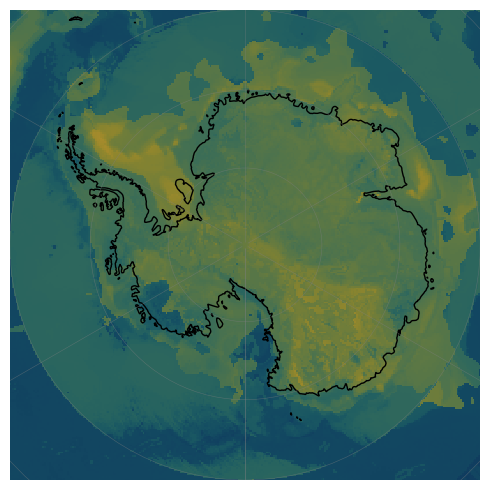

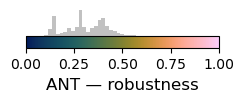

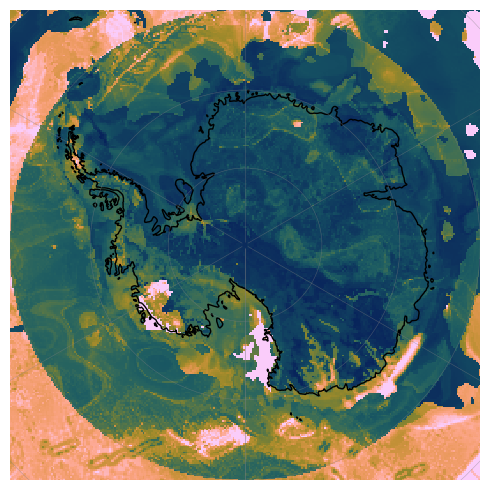

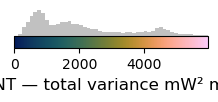

ANT: wrote robustness, total-variance, confidence and explainability maps to fig/6_CLUSTERING


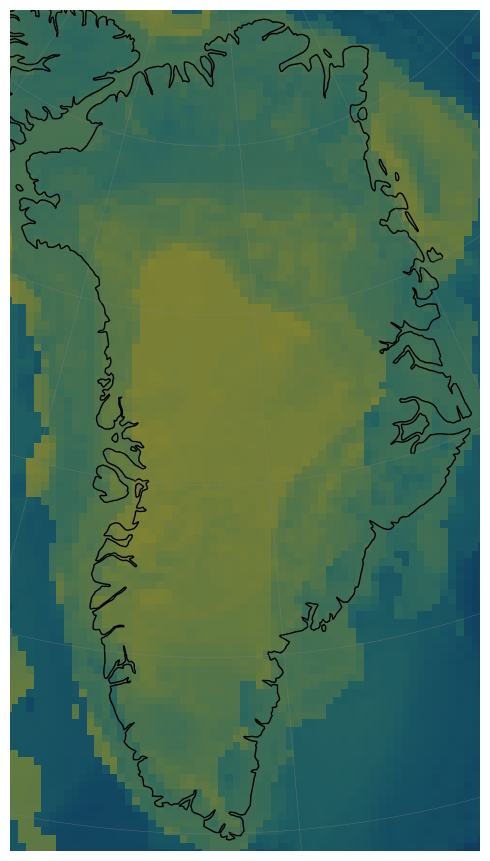

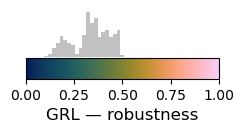

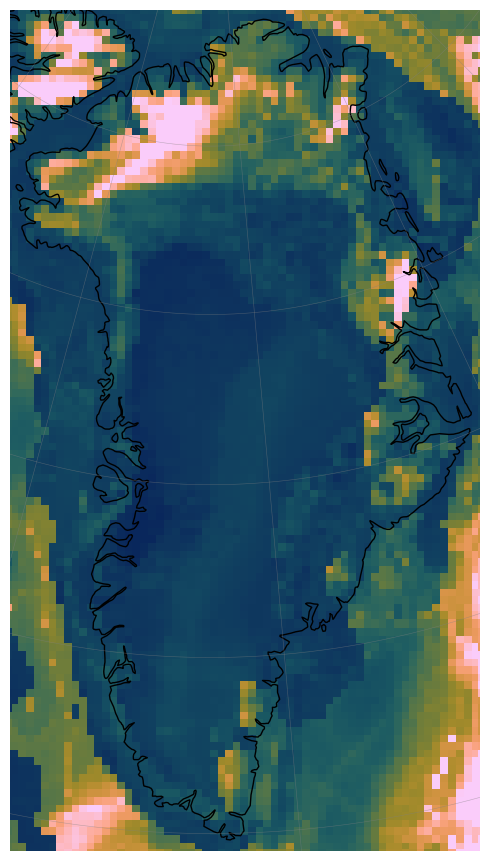

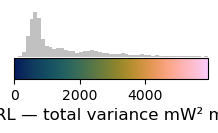

GRL: wrote robustness, total-variance, confidence and explainability maps to fig/6_CLUSTERING


In [13]:
# Figs 9-10 equivalents — every panel is now an agrid map (coastlines, graticule,
# polar CRS). Robustness and total variance are continuous (map + histogram cbar);
# confidence and explainability are categorical (classified map + legend). One
# file per field, per region, so nothing is baked into a fixed 2-panel layout.
var_total_vmax = {}   # remember the 98th-percentile variance cap per region for S1

for domain, cfg in DOMAIN_CONFIG.items():
    diag = grid_diag[domain]
    df_tgt = pd.read_parquet(cfg["parquet"])

    # (a) Robustness 1 - H_n  ∈ [0, 1]   — continuous
    result_map(df_tgt, cfg, diag["robustness"],
               cmap=robust_cmap, vmin=robust_v_min, vmax=robust_v_max,
               cbar_title=f"{domain.upper()} — robustness", units=robust_unit,
               stem=f"{domain}_fig9a_robustness", show=SHOW_FIGS)

    # (b) Total variance  — continuous, in mW² m⁻⁴
    var_mW2 = to_mW(to_mW(diag["variance_total"]))
    vmax = float(np.nanpercentile(var_mW2, VAR_PCTL_CAP))
    var_total_vmax[domain] = vmax
    result_map(df_tgt, cfg, var_mW2,
               cmap=var_cmap, vmin=0.0, vmax=vmax,
               cbar_title=f"{domain.upper()} — total variance", units=var_unit,
               stem=f"{domain}_fig9b_total_variance", show=SHOW_FIGS)

    # (a) Confidence, 5-class scheme + Unclassified — categorical (eqs 6-10)
    categorical_map(df_tgt, cfg, diag["confidence"],
                    colors=CONF_COLORS, labels=CONF_LABELS,
                    stem=f"{domain}_fig10a_confidence", show=SHOW_FIGS)

    # (b) Explainability, aleatoric/epistemic regime + extras — categorical (eqs 11-14)
    categorical_map(df_tgt, cfg, diag["explainability"],
                    colors=EXPL_COLORS, labels=EXPL_LABELS,
                    stem=f"{domain}_fig10b_explainability", show=SHOW_FIGS)

    print(f"{domain.upper()}: wrote robustness, total-variance, confidence and "
          f"explainability maps to {FIG_DIR}")


## Section 11 — Supplementary figures

Variance-decomposition maps (aleatoric vs epistemic), the cluster maps on the
target grids, and — when CV was run — a comparison of the baseline against the
Mixture-of-Experts on the out-of-fold predictions. The last panel is the direct
evidence for the paper's central claim that clustering lowers aleatoric
uncertainty.

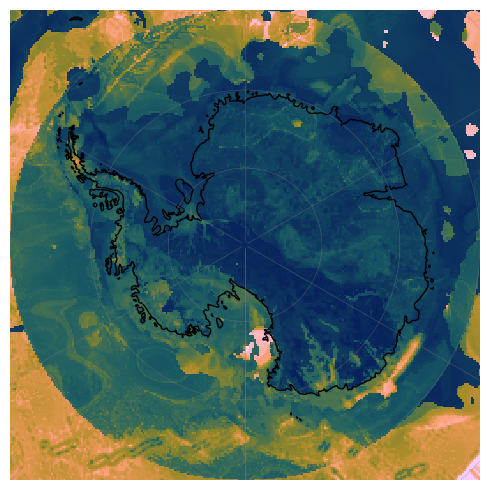

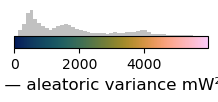

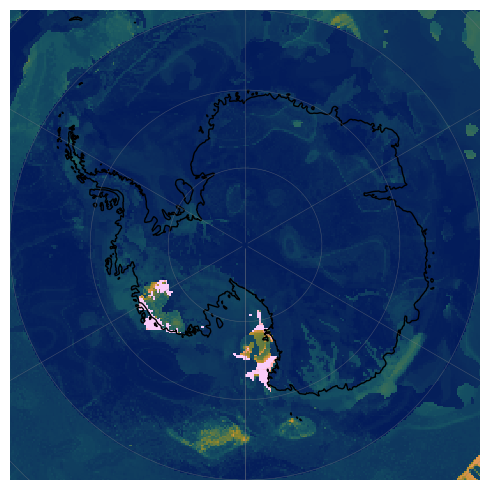

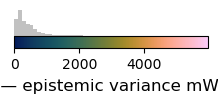

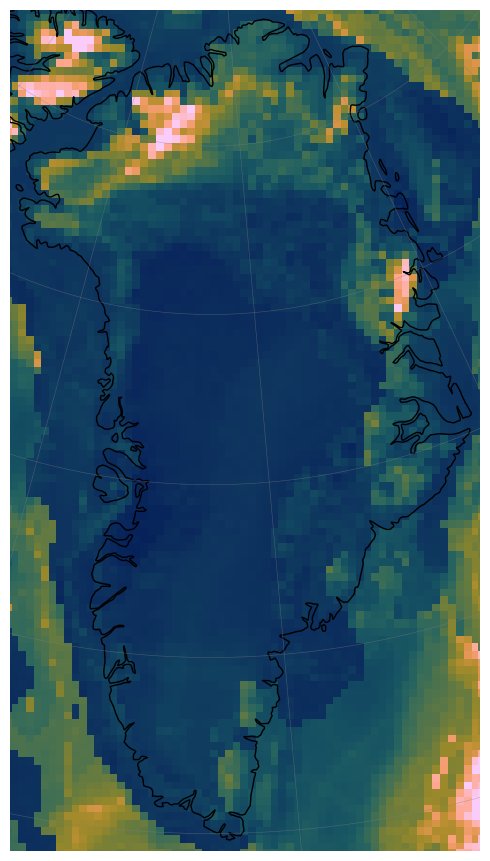

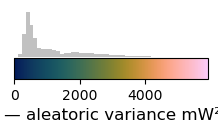

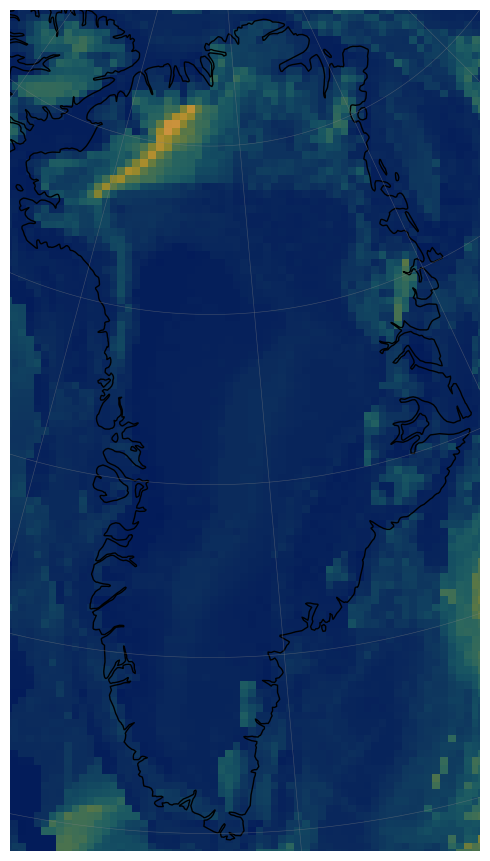

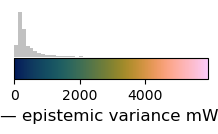

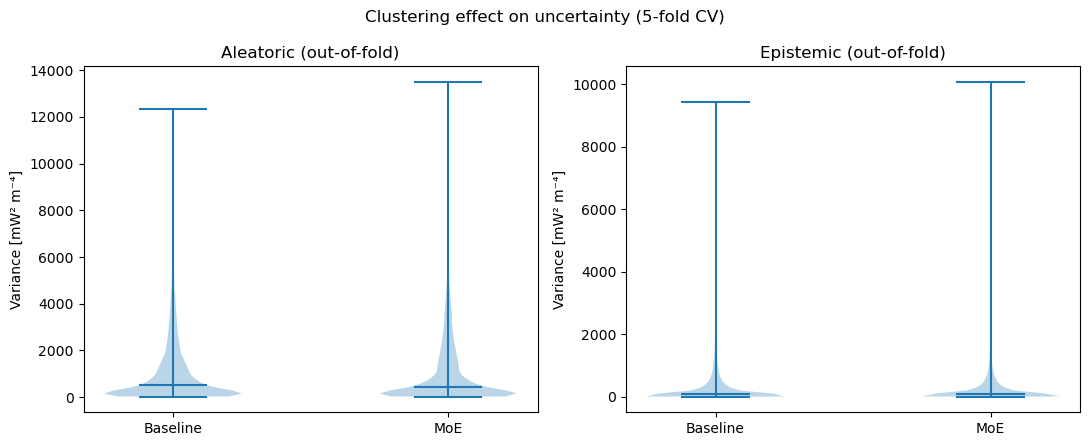

In [14]:
# S1 — variance decomposition maps (aleatoric vs epistemic), continuous.
# Same colour scale as the total-variance panel so the three are directly comparable.
for domain, cfg in DOMAIN_CONFIG.items():
    diag = grid_diag[domain]
    df_tgt = pd.read_parquet(cfg["parquet"])
    vmax = var_total_vmax.get(domain)   # reuse the total-variance cap from Figs 9-10
    for key, tag in (("variance_aleatoric", "aleatoric"),
                     ("variance_epistemic", "epistemic")):
        v = to_mW(to_mW(diag[key]))
        cap = vmax if vmax is not None else float(np.nanpercentile(v, VAR_PCTL_CAP))
        result_map(df_tgt, cfg, v, cmap=var_cmap, vmin=0.0, vmax=cap,
                   cbar_title=f"{domain.upper()} — {tag} variance", units=var_unit,
                   stem=f"S1_{domain}_variance_{tag}", show=SHOW_FIGS)

# S2 — regime (cluster) maps, categorical. Colours are sampled from the shared
# CLUSTER_CMAP so the number of swatches always matches K.
_cl_cmap = plt.get_cmap(CLUSTER_CMAP)
CLUSTER_COLORS = [mcolors.to_hex(_cl_cmap(i / max(NCLUSTERS_BEST - 1, 1)))
                  for i in range(NCLUSTERS_BEST)]
CLUSTER_LABELS = [f"Cluster {i}" for i in range(NCLUSTERS_BEST)]
for domain, cfg in DOMAIN_CONFIG.items():
    df_tgt = pd.read_parquet(cfg["parquet"])
    df_lbl = pd.read_parquet(CLUSTER_DIR / f"{domain}_cluster_labels.parquet")
    labels = df_lbl[f"cluster_n{NCLUSTERS_BEST}"].astype(float).values
    categorical_map(df_tgt, cfg, labels,
                    colors=CLUSTER_COLORS, labels=CLUSTER_LABELS,
                    stem=f"S2_{domain}_cluster_map", show=SHOW_FIGS)

# S3 — baseline vs MoE out-of-fold uncertainty. This is a distributional summary,
# not a spatial field, so it stays a plain matplotlib violin plot.
if oof_moe is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, key, title in zip(axes, ("aleat", "epist"), ("Aleatoric", "Epistemic")):
        data = [to_mW(to_mW(oof_base[key][np.isfinite(oof_base[key])])),
                to_mW(to_mW(oof_moe[key][np.isfinite(oof_moe[key])]))]
        ax.violinplot(data, showmedians=True)
        ax.set_xticks([1, 2]); ax.set_xticklabels(["Baseline", "MoE"])
        ax.set_ylabel("Variance [mW² m⁻⁴]"); ax.set_title(f"{title} (out-of-fold)")
    fig.suptitle("Clustering effect on uncertainty (5-fold CV)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"S3_cv_uncertainty_baseline_vs_moe{FIG_EXT}",
                dpi=FIG_DPI, bbox_inches="tight")
    plt.show() if SHOW_FIGS else plt.close(fig)


## Section 12 — Reading the regimes geologically

The clusters are not just statistical partitions; they should line up with the
tectonic and lithospheric structure that actually controls heat flow. This is
where the qualitative geological and glaciological discussion for the paper
starts. A few things worth checking against the maps above and confirming in the
final text:

- **East Antarctic craton.** Thick, cold, seismically fast lithosphere. Expect a
  low-heat-flow regime with narrow bandwidth and high robustness (a well-sampled,
  internally consistent regime), i.e. mostly "High confidence".
- **West Antarctic Rift System and Marie Byrd Land.** Thinned lithosphere, active
  and Pleistocene volcanism, elevated and spatially variable heat flow. Expect a
  higher-variance regime; where reference points are scarce this should show up
  as *epistemic*-dominated on the explainability map — a call for more data, not
  better instruments.
- **Greenland — the northeast track and the central anomaly.** The proposed
  plume track under central-east Greenland tends to separate from the cold
  cratonic north. Watch whether the regime boundary follows that structure.
- **Subglacial basins and margins.** Sediment thickness and topographic setting
  often carve out their own regime; high *aleatoric* variance there points to
  genuinely noisy or heterogeneous observables rather than model ignorance.

The cell below prints per-regime centroids in physical units to support this
narrative — which observables define each regime, and how the predicted heat
flow differs between them.

In [15]:
# Per-regime observable centroids (original units) + predicted GHF summary
centroids = clust_scaler.inverse_transform(best_km.cluster_centers_)
cent_df = pd.DataFrame(centroids, columns=cluster_cols).round(3)
cent_df.index = [f"Cluster {i}" for i in range(NCLUSTERS_BEST)]

ghf_rows = []
for ci in range(NCLUSTERS_BEST):
    m = train_cluster_labels == ci
    ghf_rows.append(dict(Cluster=f"Cluster {ci}", n=int(m.sum()),
                         q_median_mW=round(to_mW(np.median(y_train[m])), 1),
                         q_mean_mW=round(to_mW(y_train[m].mean()), 1),
                         q_std_mW=round(to_mW(y_train[m].std()), 1)))
print("Predicted heat flow by regime (training rows):")
print(pd.DataFrame(ghf_rows).to_string(index=False))
print("\nRegime centroids (first 8 observables):")
print(cent_df.iloc[:, :8].to_string())


Predicted heat flow by regime (training rows):
  Cluster     n  q_median_mW  q_mean_mW  q_std_mW
Cluster 0  5941         70.0       86.5      63.1
Cluster 1 17112         54.0       56.6      21.7
Cluster 2  7795         72.9       85.4      53.4

Regime centroids (first 8 observables):
                MOHO  MOHO_GRAV       DEM         LAB  FREE_AIR  BOUGUER     SI   GEOID
Cluster 0 -15994.637 -15304.111 -3313.102  -80931.230     0.000    0.227 -0.088   7.958
Cluster 1 -38088.627 -32608.788   137.318 -133197.746    -0.008   -0.035 -0.091 -12.166
Cluster 2 -33338.201 -35083.849   701.586  -70015.664     0.007   -0.080  0.292  -1.671


## Section 13 — Save artefacts and the hand-off to notebook 7

Everything notebook 7 needs is written to `output/clustering/`: the regime
labels, the CV thresholds, the expert models, and the per-domain diagnostic
fields. A single `cluster_summary.json` records the run so notebook 7 can load
the correct K and paths without guessing.

Notebook 7 combines these QRF diagnostics with the GBM and similarity model
outputs from notebooks 5a–5c: it treats this MoE QRF as the primary,
regime-aware estimator, then adds a between-method (structural) uncertainty
layer on top.

In [16]:
summary = dict(
    model_version=MODEL_VERSION,
    NCLUSTERS_BEST=int(NCLUSTERS_BEST),
    coarsen_factor=int(COARSEN_FACTOR),
    native_spacing_m=int(NATIVE_SPACING_ANT),
    target_spacing_m=int(TARGET_SPACING_M),
    n_features_sel=len(obs_sel),
    n_features_clust=len(cluster_cols),
    n_train=int(len(df_ref)),
    n_cv_folds=int(N_CV_FOLDS),
    obs_sel=list(obs_sel),
    cluster_cols=list(cluster_cols),
    cv_thresholds={k: float(v) for k, v in thresholds.items()},
    cluster_diagnostics=diag_df.to_dict(orient="records"),
    outputs={
        "cluster_diagnostics_csv": str(CLUSTER_DIR / "cluster_diagnostics.csv"),
        "cv_thresholds_json":      str(CLUSTER_DIR / "cv_thresholds.json"),
        "expert_artefacts_pkl":    str(CLUSTER_DIR / f"expert_qrf_n{NCLUSTERS_BEST}.pkl"),
        "ant_cluster_labels":      str(CLUSTER_DIR / "ant_cluster_labels.parquet"),
        "grl_cluster_labels":      str(CLUSTER_DIR / "grl_cluster_labels.parquet"),
        "ant_diagnostics_pkl":     str(CLUSTER_DIR / "ant_diagnostics.pkl"),
        "grl_diagnostics_pkl":     str(CLUSTER_DIR / "grl_diagnostics.pkl"),
        "ant_25km_parquet":        str(CRS_ANT25),
        "grl_25km_parquet":        str(CRS_GRL25),
    },
)
json.dump(summary, open(CLUSTER_DIR / "cluster_summary.json", "w"), indent=2)
print(f"Saved summary -> {CLUSTER_DIR / 'cluster_summary.json'}")
print("\nOutput checklist:")
for label, path in summary["outputs"].items():
    print(f"  {'ok ' if Path(path).exists() else 'MISS'}  {label:26s}  {path}")


Saved summary -> output/clustering/cluster_summary.json

Output checklist:
  ok   cluster_diagnostics_csv     output/clustering/cluster_diagnostics.csv
  ok   cv_thresholds_json          output/clustering/cv_thresholds.json
  ok   expert_artefacts_pkl        output/clustering/expert_qrf_n3.pkl
  ok   ant_cluster_labels          output/clustering/ant_cluster_labels.parquet
  ok   grl_cluster_labels          output/clustering/grl_cluster_labels.parquet
  ok   ant_diagnostics_pkl         output/clustering/ant_diagnostics.pkl
  ok   grl_diagnostics_pkl         output/clustering/grl_diagnostics.pkl
  ok   ant_25km_parquet            data/antarctica_25km.parquet
  ok   grl_25km_parquet            data/greenland_25km.parquet


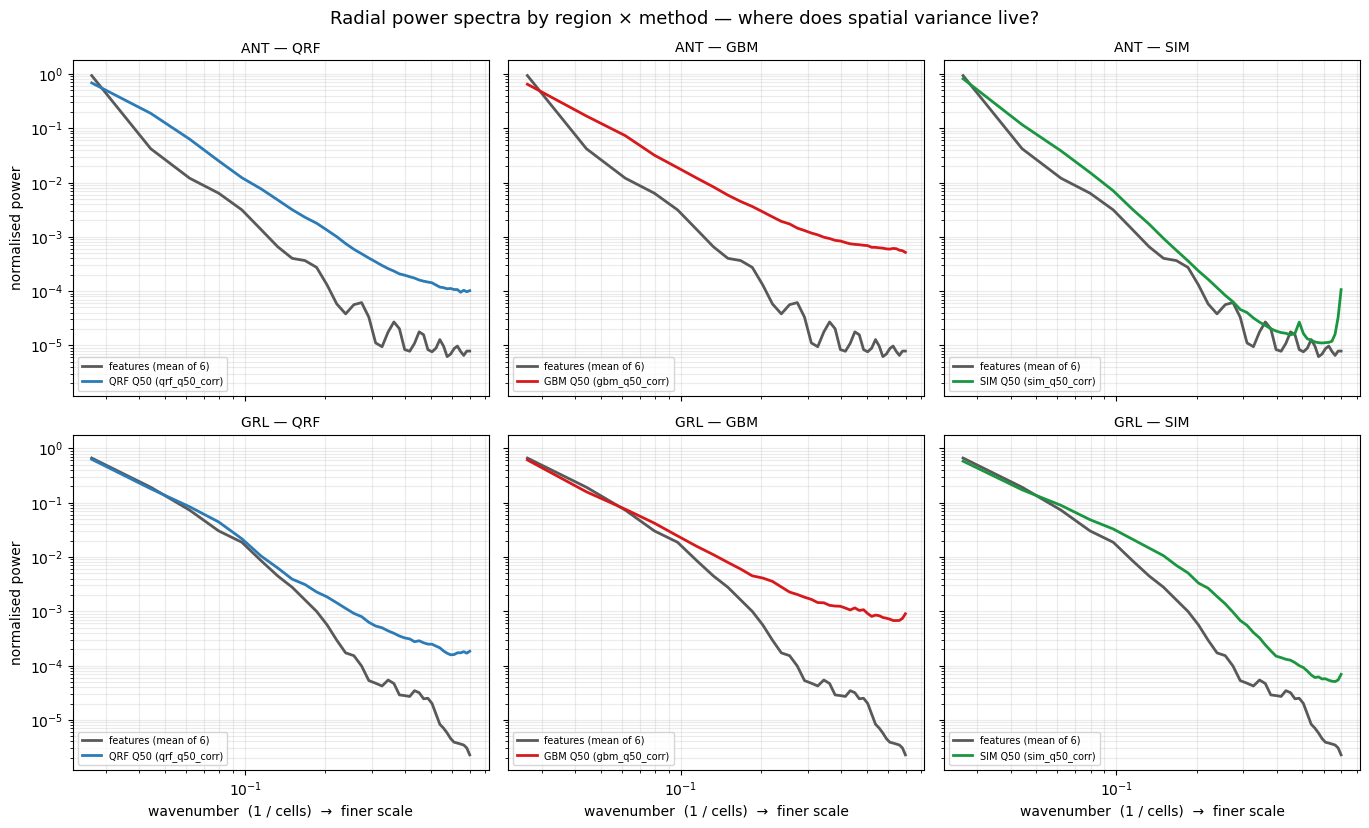

power-spectrum panel written to fig/6_CLUSTERING/D_power_spectrum_panel.png
Reading: within each panel, a method curve that drops below the feature / reference curves at high wavenumber shows the regression suppressing fine-scale variance.


In [20]:
# ── Diagnostic — radial power spectra, one panel per region × method (2×3) ────
# Read-only. Nothing here feeds back into the pipeline; it asks one question:
# does the regression step throw away spatial variance that the input features
# (and the reference observations) actually carry?
#
# Layout: rows = regions (ant, grl), cols = methods (QRF, GBM, SIM). Each panel
# overlays, on the same 25 km grid and normalised to unit total power:
#   • the mean standardised input feature field  (grey)   — information available
#   • the reference heat-flow observations        (black dashed) — target texture
#   • that panel's method Q50 prediction           (colour)
# A prediction curve that falls below the feature / reference curves at high
# wavenumber means the estimator is low-passing the ref→target connection.
# Spectra are normalised so we compare *where variance lives across scales*, not
# amplitude. Plain matplotlib — these are diagnostics, not maps.

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift, fftfreq

# --- tunables (kept local; this is a one-off diagnostic) ----------------------
# Which Q50 variable each method writes into its NetCDF. If your on-disk names
# differ, the cell also tries a few common fallbacks (see _pick_q50_var below).
PSD_METHODS = {"qrf": "qrf_q50_corr", "gbm": "gbm_q50_corr", "sim": "sim_q50_corr"}
PSD_COLORS  = {"qrf": "#2c7bb6", "gbm": "#d7191c", "sim": "#1a9641"}
PSD_N_FEAT  = 6          # how many standardised features to average for the "input" curve
PSD_DETREND = True       # remove a planar trend before the FFT (kills DC/ramp leakage)
PSD_WINDOW  = True       # 2-D Hann window before the FFT (kills edge leakage)
PSD_NBINS   = 40         # radial wavenumber bins


# --- where the result grids actually live -------------------------------------
# IMPORTANT: the *_nc constants in config.py (output/ant_Aq2_qrf.nc, …) are stale
# and never written. NB5 builds its own filenames as
#     targets_dir / f"{prefix}_{METHOD}_v{MODEL_VERSION}.nc"
# with a per-region prefix that is NOT the same across methods:
#     QRF -> Aq1_5 / Kq1_5     GBM, SIM -> Aq15 / Kq15
# So we rebuild the paths the same way NB5 does. This needs no setup cell and
# tracks MODEL_VERSION automatically. Edit PSD_PREFIX / PSD_VERSION below only if
# your naming scheme changes. A manual PSD_NC_PATHS override (if defined in scope)
# still wins.
PSD_PREFIX  = {"ant": ("Aq1_5", "Aq15"), "grl": ("Kq1_5", "Kq15")}   # (QRF, GBM/SIM)
PSD_VERSION = MODEL_VERSION if "MODEL_VERSION" in globals() else "0_4"


def _nb5_paths(region):
    """Rebuild the NB5 target-grid paths for one region (matches 5a/5b/5c)."""
    tdir = targets_dir if "targets_dir" in globals() else Path("output/targets")
    pq, pgs = PSD_PREFIX.get(region, (region, region))
    return {
        "qrf": str(Path(tdir) / f"{pq}_QRF_v{PSD_VERSION}.nc"),
        "gbm": str(Path(tdir) / f"{pgs}_GBM_v{PSD_VERSION}.nc"),
        "sim": str(Path(tdir) / f"{pgs}_SIM_v{PSD_VERSION}.nc"),
    }


# Region metadata (parquet + x/y column names) comes from TARGET_GRIDS or the
# older DOMAIN_CONFIG dict; the NetCDF paths always come from _nb5_paths (unless
# a manual PSD_NC_PATHS override is present).
def _build_region_cfg():
    out = {}
    if "TARGET_GRIDS" in globals():
        for g in TARGET_GRIDS:
            reg = g["label"]
            out[reg] = dict(
                parquet=g["parquet"],
                xcol=g.get("x_col", g.get("xcol", "x")),
                ycol=g.get("y_col", g.get("ycol", "y")),
                nc=_nb5_paths(reg),
            )
    elif "DOMAIN_CONFIG" in globals():
        for label, d in DOMAIN_CONFIG.items():
            out[label] = dict(
                parquet=d["parquet"],
                xcol=d.get("xcol", d.get("x_col", "x")),
                ycol=d.get("ycol", d.get("y_col", "y")),
                nc=_nb5_paths(label),
            )
    # a manual override, if the user set one, always wins
    if "PSD_NC_PATHS" in globals():
        for reg, mm in PSD_NC_PATHS.items():
            if reg in out:
                out[reg]["nc"].update({k: v for k, v in mm.items() if v})
    return out


def _pick_q50_var(ds, meth):
    """Find this method's Q50 variable in a NetCDF, tolerant of naming drift."""
    want = PSD_METHODS.get(meth, "")
    if want and want in ds.variables:
        return want
    cands = [v for v in ds.variables
             if meth in v.lower() and ("q50" in v.lower() or "50" in v.lower())]
    if cands:                                   # prefer a "corrected" variable if present
        cands.sort(key=lambda v: ("corr" not in v.lower(), len(v)))
        return cands[0]
    generic = [v for v in ds.variables if "q50" in v.lower()]
    return generic[0] if generic else None


def _grid_2d(df, xcol, ycol, values):
    """Flat (x, y, value) -> dense 2-D array on the regular grid (NaN where empty)."""
    d = df[[xcol, ycol]].copy()
    d["_v"] = np.asarray(values, dtype=float)
    p = d.pivot_table(index=ycol, columns=xcol, values="_v", aggfunc="mean")
    return p.values, p.columns.values, p.index.values   # (ny, nx), xs, ys


def _bin_points_to_grid(px, py, pv, xs, ys):
    """Bin scattered reference points onto the target grid cells (mean per cell)."""
    ny, nx = len(ys), len(xs)
    dx = np.median(np.diff(xs)); dy = np.median(np.diff(ys))
    ix = np.round((px - xs[0]) / dx).astype(int)
    iy = np.round((py - ys[0]) / dy).astype(int)
    ok = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny) & np.isfinite(pv)
    acc = np.full((ny, nx), np.nan); cnt = np.zeros((ny, nx))
    for xi, yi, v in zip(ix[ok], iy[ok], pv[ok]):
        acc[yi, xi] = v if np.isnan(acc[yi, xi]) else acc[yi, xi] + v
        cnt[yi, xi] += 1
    with np.errstate(invalid="ignore"):
        return np.where(cnt > 0, acc / np.maximum(cnt, 1), np.nan)


def _radial_psd(field, nbins=PSD_NBINS):
    """Radially-averaged 2-D power spectrum, normalised to unit total power.

    NaNs are filled with the field mean; a planar trend and a 2-D Hann window are
    removed first so the slope reflects real spatial structure, not edge/DC
    leakage. Returns (k_norm, power_norm), or (None, None) if too few valid cells.
    """
    a = np.array(field, dtype=float)
    m = np.isfinite(a)
    if m.sum() < 16:
        return None, None
    a = np.where(m, a, np.nanmean(a[m]))

    ny, nx = a.shape
    if PSD_DETREND:                                  # remove best-fit plane
        yy, xx = np.mgrid[0:ny, 0:nx]
        A = np.c_[xx.ravel(), yy.ravel(), np.ones(a.size)]
        coef, *_ = np.linalg.lstsq(A, a.ravel(), rcond=None)
        a = a - (A @ coef).reshape(ny, nx)
    else:
        a = a - a.mean()
    if PSD_WINDOW:                                   # 2-D Hann taper
        a = a * (np.hanning(ny)[:, None] * np.hanning(nx)[None, :])

    P = np.abs(fftshift(fft2(a))) ** 2
    KX, KY = np.meshgrid(fftshift(fftfreq(nx)), fftshift(fftfreq(ny)))
    K = np.sqrt(KX ** 2 + KY ** 2)

    edges = np.linspace(0, K.max(), nbins + 1)
    idx = np.clip(np.digitize(K.ravel(), edges) - 1, 0, nbins - 1)
    power = np.bincount(idx, weights=P.ravel(), minlength=nbins)
    count = np.bincount(idx, minlength=nbins)
    with np.errstate(invalid="ignore"):
        prof = power / np.maximum(count, 1)
    kcen = 0.5 * (edges[:-1] + edges[1:])

    prof = prof[1:]; kcen = kcen[1:]                 # drop the DC bin
    tot = np.nansum(prof)
    if tot > 0:
        prof = prof / tot                            # unit total power -> shape only
    return kcen, prof


# --- build the 2×3 panel ------------------------------------------------------
try:
    import netCDF4 as _nc

    region_cfg = _build_region_cfg()
    if not region_cfg:
        raise RuntimeError("no region config found — expected TARGET_GRIDS or DOMAIN_CONFIG in scope")

    _ref = pd.read_parquet(parquet_ref)

    regions = list(region_cfg.keys())
    methods = list(PSD_METHODS.keys())
    nrow, ncol = len(regions), len(methods)

    fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 4.2 * nrow),
                             squeeze=False, sharex=True, sharey=True)

    for r, domain in enumerate(regions):
        rc = region_cfg[domain]
        xc, yc = rc["xcol"], rc["ycol"]
        df_tgt = pd.read_parquet(rc["parquet"])

        # (1) mean standardised input feature field — computed once per region
        feats = [f for f in obs_model if f in df_tgt.columns][:PSD_N_FEAT]
        Fz = (df_tgt[feats].astype(float) - df_tgt[feats].astype(float).mean()) \
             / df_tgt[feats].astype(float).std(ddof=0)
        g_feat, xs, ys = _grid_2d(df_tgt, xc, yc, Fz.mean(axis=1).values)
        k_feat, p_feat = _radial_psd(g_feat)

        # (2) reference observations binned to the grid — computed once per region
        rr = _ref
        if "region" in rr.columns:
            rr = rr[rr["region"].astype(str).str.lower().str.startswith(domain[:3])]
        k_ref = p_ref = None; n_ref_cells = 0
        if {"x", "y", "q"}.issubset(rr.columns) and len(rr):
            g_ref = _bin_points_to_grid(rr["x"].values, rr["y"].values, rr["q"].values, xs, ys)
            n_ref_cells = int(np.isfinite(g_ref).sum())
            k_ref, p_ref = _radial_psd(g_ref)

        # (3) one panel per method
        for c, meth in enumerate(methods):
            ax = axes[r][c]
            if k_feat is not None:
                ax.loglog(k_feat, p_feat, lw=2.0, color="0.35",
                          label=f"features (mean of {len(feats)})")
            if k_ref is not None:
                ax.loglog(k_ref, p_ref, lw=2.0, color="k", ls="--",
                          label=f"reference obs (n={n_ref_cells})")

            path = rc["nc"].get(meth)
            drawn = False
            if path is None:
                print(f"  [{domain}] {meth}: no NetCDF path in config")
            elif not Path(path).exists():
                print(f"  [{domain}] {meth}: {path} not found")
            else:
                with _nc.Dataset(path) as ds:
                    var = _pick_q50_var(ds, meth)
                    if var is None:
                        print(f"  [{domain}] {meth}: no Q50 variable in {path} "
                              f"(has: {list(ds.variables)[:8]}…)")
                    else:
                        arr = np.asarray(ds.variables[var][:], dtype=float)
                        g_pred = _grid_2d(df_tgt, xc, yc, arr.ravel())[0] if arr.ndim == 1 else arr
                        k_p, p_p = _radial_psd(g_pred)
                        if k_p is not None:
                            ax.loglog(k_p, p_p, lw=2.0, color=PSD_COLORS[meth],
                                      label=f"{meth.upper()} Q50 ({var})")
                            drawn = True
            if not drawn:
                ax.text(0.5, 0.5, f"{meth.upper()} Q50\n(not available)",
                        transform=ax.transAxes, ha="center", va="center",
                        fontsize=9, color="0.5")

            ax.set_title(f"{domain.upper()} — {meth.upper()}", fontsize=10)
            ax.grid(True, which="both", alpha=0.25)
            ax.legend(fontsize=7, loc="lower left")
            if r == nrow - 1:
                ax.set_xlabel("wavenumber  (1 / cells)  →  finer scale")
            if c == 0:
                ax.set_ylabel("normalised power")

    fig.suptitle("Radial power spectra by region × method — where does spatial variance live?",
                 fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"D_power_spectrum_panel{FIG_EXT}", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    print(f"power-spectrum panel written to {FIG_DIR / f'D_power_spectrum_panel{FIG_EXT}'}")
    print("Reading: within each panel, a method curve that drops below the feature / "
          "reference curves at high wavenumber shows the regression suppressing fine-scale variance.")
except FileNotFoundError as e:
    print("power-spectrum diagnostic skipped —", e)


In [19]:
from pathlib import Path
for reg,(pq,pgs) in {"ant":("Aq1_5","Aq15"),"grl":("Kq1_5","Kq15")}.items():
    for m,pre in [("QRF",pq),("GBM",pgs),("SIM",pgs)]:
        p = targets_dir / f"{pre}_{m}_v{MODEL_VERSION}.nc"
        print(reg, m, p, "exists=", Path(p).exists())

ant QRF output/targets/Aq1_5_QRF_v0_4.nc exists= True
ant GBM output/targets/Aq15_GBM_v0_4.nc exists= True
ant SIM output/targets/Aq15_SIM_v0_4.nc exists= True
grl QRF output/targets/Kq1_5_QRF_v0_4.nc exists= True
grl GBM output/targets/Kq15_GBM_v0_4.nc exists= True
grl SIM output/targets/Kq15_SIM_v0_4.nc exists= True
